1. Train a model to predict the fare of a taxi ride in Chicago, Illinois with the dataset, City of Chicago Taxi Trips dataset.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import kagglehub
import os

In [ ]:
path = kagglehub.dataset_download(
    "adelanseur/taxi-trips-chicago-2024"
)

print("Path to dataset files:", path)

100%|██████████| 111M/111M [00:00<00:00, 186MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adelanseur/taxi-trips-chicago-2024/versions/1


In [ ]:
print(os.listdir(path))

['Taxi_Trips_-_2024_20240408.csv']


In [ ]:
data = pd.read_csv(
    f"{path}/Taxi_Trips_-_2024_20240408.csv"
)

data.head()

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,0287f53fedcde6b0af9aab9e32cbd2cadb337eaa,e54db25f18193a08f1f5754515e8c338480e04fb938ed3...,03/01/2024 12:00:00 AM,03/01/2024 12:00:00 AM,15.0,0.09,NaN,NaN,8.0,8.0,...,35.0,38.75,Credit Card,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,1f0034299b914fd7b45002568576a353c83acb2f,4a263f78f56815be4acd38658af8fc1824ce4e15f7ec81...,03/01/2024 12:00:00 AM,03/01/2024 12:15:00 AM,900.0,3.00,NaN,NaN,24.0,8.0,...,0.0,12.00,Cash,Taxi Affiliation Services,41.901207,-87.676356,POINT (-87.6763559892 41.9012069941),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
2,01a0b77b722a0b91f45cb4fc90b3e64f76fd0681,4f1e94982e6851725add382f7981d64006ae7c38f3664f...,03/01/2024 12:00:00 AM,03/01/2024 12:00:00 AM,711.0,5.84,NaN,NaN,56.0,NaN,...,5.0,26.70,Credit Card,City Service,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),NaN,NaN,NaN
3,14aff2071ac81c6450a8f8b0e1534497da900197,de8e8659ceb9eb0da842a46b60c0a5207098ac69fc23ab...,03/01/2024 12:00:00 AM,03/01/2024 12:30:00 AM,1770.0,13.36,NaN,NaN,76.0,3.0,...,4.0,47.10,Credit Card,Sun Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)
4,16d3a633e2f380cee4a7fa4677db163b6e91255d,d79d3e19a1d5f6cb0cd4449d5579412262a2f1b182799d...,03/01/2024 12:00:00 AM,03/01/2024 12:15:00 AM,849.0,6.13,NaN,NaN,8.0,3.0,...,0.0,22.82,Mobile,5 Star Taxi,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)


In [ ]:
df = pd.read_csv(
    f"{path}/Taxi_Trips_-_2024_20240408.csv"
)

In [ ]:
print("Number of rows:", df.shape[0])

print("Number of columns:", df.shape[1])

print("\nColumn names:")

print(df.columns.tolist())

Number of rows: 865247
Number of columns: 23

Column names:
['Trip ID', 'Taxi ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds', 'Trip Miles', 'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area', 'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras', 'Trip Total', 'Payment Type', 'Company', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude', 'Pickup Centroid Location', 'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude', 'Dropoff Centroid  Location']


In [ ]:
df.describe()

,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Pickup Centroid Latitude,Pickup Centroid Longitude,Dropoff Centroid Latitude,Dropoff Centroid Longitude
count,865078.000000,865241.000000,3.272510e+05,3.138540e+05,842052.000000,781394.000000,863202.000000,863202.000000,863202.000000,863202.000000,863202.000000,842281.000000,842281.000000,785572.000000,785572.000000
mean,1150.532018,6.563330,1.703152e+10,1.703141e+10,36.660485,25.853590,22.057441,2.761349,0.063232,2.149285,27.204886,41.902214,-87.704695,41.892124,-87.659592
std,1584.243513,8.279528,3.721479e+05,3.392339e+05,26.416845,20.501911,25.145823,4.132953,12.955213,19.319780,40.989308,0.066429,0.115525,0.059498,0.067986
min,0.000000,0.000000,1.703101e+10,1.703101e+10,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,41.660136,-87.913625,41.650222,-87.913625
25%,459.000000,0.910000,1.703108e+10,1.703108e+10,8.000000,8.000000,8.000000,0.000000,0.000000,0.000000,10.000000,41.878866,-87.769615,41.878866,-87.663518
50%,900.000000,3.070000,1.703132e+10,1.703132e+10,32.000000,28.000000,15.750000,0.000000,0.000000,0.000000,18.780000,41.898332,-87.642649,41.892508,-87.633308
75%,1591.000000,11.710000,1.703198e+10,1.703184e+10,69.000000,32.000000,33.750000,4.000000,0.000000,3.000000,40.900000,41.979071,-87.626146,41.922686,-87.625192
max,86340.000000,3093.470000,1.703198e+10,1.703198e+10,77.000000,77.000000,9999.750000,200.000000,4444.440000,5051.100000,9999.750000,42.021224,-87.534903,42.021224,-87.534903


In [ ]:
data = data[['Trip Miles', 'Trip Total']]

data.shape

(865247, 2)

In [ ]:
data.dropna(inplace=True)

data.isnull().sum()


,0
Trip Miles,0
Trip Total,0


In [ ]:
x = data.iloc[:, :1].values
y = data.iloc[:, 1:2].values

print(x)
print(y)

[[ 0.09]
 [ 3.  ]
 [ 5.84]
 ...
 [17.44]
 [ 3.07]
 [ 1.49]]
[[38.75]
 [12.  ]
 [26.7 ]
 ...
 [66.3 ]
 [26.  ]
 [12.25]]


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

y_pred

array([[42.1919655 ],
       [28.15969042],
       [12.27758623],
       ...,
       [ 9.81995614],
       [48.63994124],
       [48.11141863]])

In [ ]:
model.score(x_test, y_test)

0.1719224457128684

In [ ]:
print(y_test)
print(y_pred)

[[31.25]
 [24.98]
 [ 8.75]
 ...
 [45.25]
 [43.5 ]
 [50.4 ]]
[[42.1919655 ]
 [28.15969042]
 [12.27758623]
 ...
 [ 9.81995614]
 [48.63994124]
 [48.11141863]]


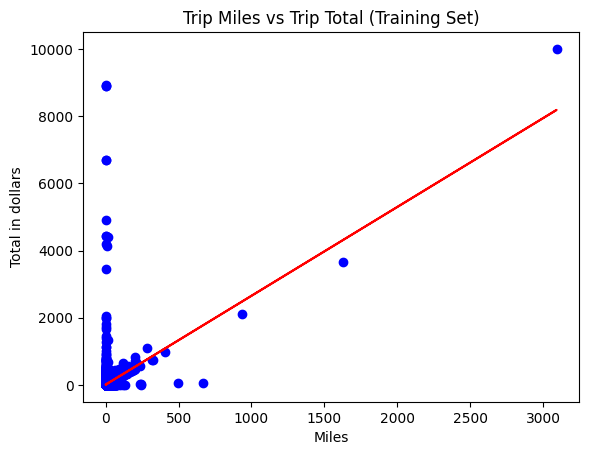

In [ ]:
plt.scatter(x_train, y_train, color='blue')

plt.plot(
    x_train,
    model.predict(x_train),
    color='red'
)

plt.title('Trip Miles vs Trip Total (Training Set)')
plt.xlabel('Miles')
plt.ylabel('Total in dollars')

plt.show()

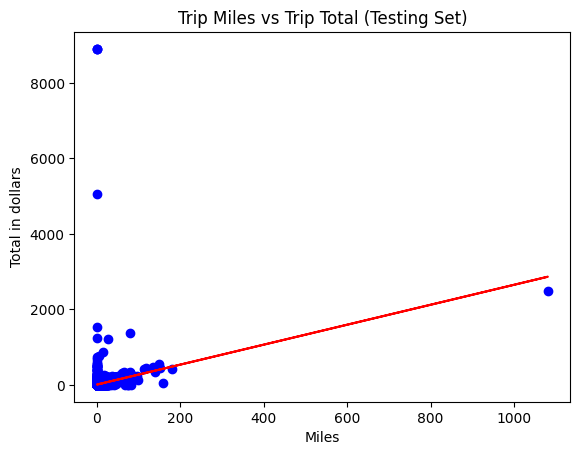

In [ ]:
plt.scatter(x_test, y_test, color='blue')

plt.plot(
    x_test,
    model.predict(x_test),
    color='red'
)

plt.title('Trip Miles vs Trip Total (Testing Set)')
plt.xlabel('Miles')
plt.ylabel('Total in dollars')

plt.show()

2. Conduct Linear regression on a model that predicts the body weight of a person. The dependent variable is thus the body weight, while the height, age and gender are chosen as independent variables. The following example data set is available:

| Weight | Height | Age | Gender |
| -----: | -----: | --: | ------ |
|     79 |   1.80 |  35 | Male   |
|     69 |   1.68 |  39 | Male   |
|     73 |   1.82 |  25 | Male   |
|     95 |   1.70 |  60 | Male   |
|     82 |   1.87 |  27 | Male   |
|     55 |   1.55 |  18 | Female |
|     69 |   1.50 |  89 | Female |
|     71 |   1.78 |  42 | Female |
|     64 |   1.67 |  16 | Female |
|     69 |   1.64 |  52 | Female |


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

Enter the given dataset

In [ ]:
data = pd.DataFrame({
    'Weight': [79, 69, 73, 95, 82, 55, 69, 71, 64, 69],
    'Height': [1.80, 1.68, 1.82, 1.70, 1.87, 1.55, 1.50, 1.78, 1.67, 1.64],
    'Age': [35, 39, 25, 60, 27, 18, 89, 42, 16, 52],
    'Gender': ['Male', 'Male', 'Male', 'Male', 'Male',
               'Female', 'Female', 'Female', 'Female', 'Female']
})

data

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.55,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


Convert Gender

In [ ]:
data['Gender'] = data['Gender'].replace({
    'Female': 0,
    'Male': 1
})

data

/tmp/ipykernel_2384/3578139063.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({


,Weight,Height,Age,Gender
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1
5,55,1.55,18,0
6,69,1.50,89,0
7,71,1.78,42,0
8,64,1.67,16,0
9,69,1.64,52,0


Check shape

In [ ]:
data.shape

(10, 4)

Check null values

In [ ]:
data.isnull().sum()

,0
Weight,0
Height,0
Age,0
Gender,0


Separate X and Y

In [ ]:
x = data.iloc[:, 1:].values
y = data.iloc[:, :1].values

print(x)
print(y)

[[ 1.8  35.    1.  ]
 [ 1.68 39.    1.  ]
 [ 1.82 25.    1.  ]
 [ 1.7  60.    1.  ]
 [ 1.87 27.    1.  ]
 [ 1.55 18.    0.  ]
 [ 1.5  89.    0.  ]
 [ 1.78 42.    0.  ]
 [ 1.67 16.    0.  ]
 [ 1.64 52.    0.  ]]
[[79]
 [69]
 [73]
 [95]
 [82]
 [55]
 [69]
 [71]
 [64]
 [69]]


Split training and testing dat

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

create Linear Regression model

In [ ]:
model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

y_pred

array([[56.85651025],
       [79.10576115]])

Print actual values

In [ ]:
print(y_test)

[[64]
 [69]]


Print predicted values

In [ ]:
print(y_pred)

[[56.85651025]
 [79.10576115]]


Check model score

In [ ]:
model.score(x_test, y_test)

-11.252468343750825

Training graph

Because this is multiple linear regression, we can show Height against Weight while keeping Age and Gender fixed

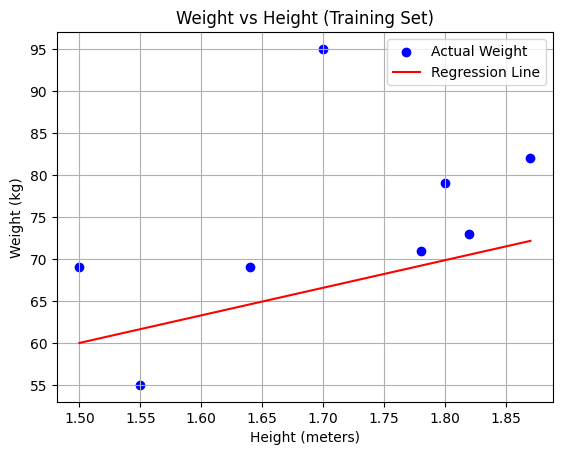

In [ ]:
import numpy as np

x_train_height = x_train[:, 0]

plt.scatter(
    x_train_height,
    y_train,
    color='blue',
    label='Actual Weight'
)

mean_age = x_train[:, 1].mean()

mode_gender = pd.Series(
    x_train[:, 2].astype(int)
).mode()[0]

height_range = np.linspace(
    x_train_height.min(),
    x_train_height.max(),
    100
)

regression_data = np.array([
    [h, mean_age, mode_gender]
    for h in height_range
])

predicted_weight = model.predict(regression_data)

plt.plot(
    height_range,
    predicted_weight,
    color='red',
    label='Regression Line'
)

plt.title('Weight vs Height (Training Set)')
plt.xlabel('Height (meters)')
plt.ylabel('Weight (kg)')
plt.legend()
plt.grid(True)

plt.show()

Testing graph

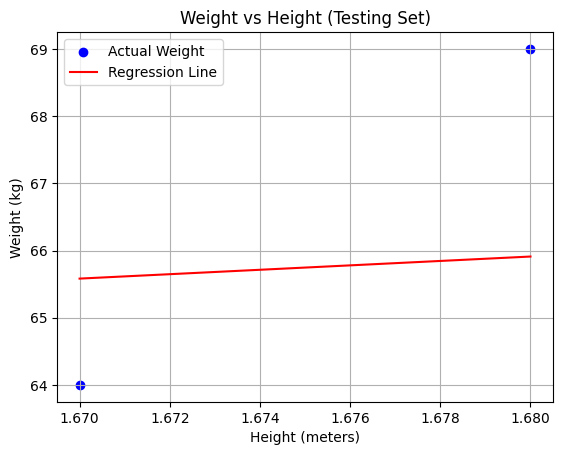

In [ ]:
x_test_height = x_test[:, 0]

plt.scatter(
    x_test_height,
    y_test,
    color='blue',
    label='Actual Weight'
)

height_range_test = np.linspace(
    x_test_height.min(),
    x_test_height.max(),
    100
)

regression_data_test = np.array([
    [h, mean_age, mode_gender]
    for h in height_range_test
])

predicted_weight_test = model.predict(
    regression_data_test
)

plt.plot(
    height_range_test,
    predicted_weight_test,
    color='red',
    label='Regression Line'
)

plt.title('Weight vs Height (Testing Set)')
plt.xlabel('Height (meters)')
plt.ylabel('Weight (kg)')
plt.legend()
plt.grid(True)

plt.show()